In [2]:
import pandas as pd
import pandas as pd
import numpy as np

# ── Load raw data ──────────────────────────────────────────────────────────────
df_all_years_prices = pd.read_csv(
    r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar'
    r'\Model_BESS\bess-optimierung-tool-py312\bess-behind-the-meter'
    r'\data\Spot-Arbitrage\spot_price_CH_ab_2023.csv'
)



# ── Assign DatetimeIndex to prices ─────────────────────────────────────────────
df_all_years_prices['Date'] = pd.date_range(
    start='2023-01-01', periods=len(df_all_years_prices), freq='h'
)
df_all_years_prices.index = df_all_years_prices['Date']

df_all_years_prices = df_all_years_prices[['Spot CH', 'Date']]

# ── Split prices by year first ─────────────────────────────────────────────────
def split_by_year(df: pd.DataFrame, date_col: str = 'Date') -> list[pd.DataFrame]:
    """Split a DataFrame into a list of yearly DataFrames, sorted by year."""
    return [
        group.reset_index(drop=True)
        for _, group in df.groupby(df[date_col].dt.year)
    ]

list_prices: list[pd.DataFrame] = split_by_year(df_all_years_prices)


# ── Sanity check ───────────────────────────────────────────────────────────────
print(f"Years in prices : {[df['Date'].dt.year.iloc[0] for df in list_prices]}")
print(f"Rows per price  : {[len(df) for df in list_prices]}")



Years in prices : [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037]
Rows per price  : [8760, 8784, 8760, 8760, 8760, 8784, 8760, 8760, 8760, 8784, 8760, 8760, 8760, 8784, 8760]


In [ ]:
import matplotlib.pyplot as plt

def amplify_volatility(
    df: pd.DataFrame,
    price_col: str,
    date_col: str,
    factor: float,
    anchor: str = 'daily',          # 'daily' | 'weekly' | 'monthly'
    floor: float | None = None,     # optional price floor (e.g. 0.0)
) -> pd.DataFrame:
    """
    Amplify price volatility around a chosen mean anchor while preserving
    the shape of the curve and cheaper midday prices.

    Parameters
    ----------
    df       : DataFrame with a datetime date_col and a numeric price_col.
    price_col: Name of the price column to amplify.
    date_col : Name of the datetime column.
    factor   : Volatility multiplier (>1 increases spread, <1 dampens it).
               e.g. factor=1.5 → deviations from mean are 50% larger.
    anchor   : Period whose mean is preserved:
               'daily'   → each day's average stays the same
               'weekly'  → each week's average stays the same
               'monthly' → each month's average stays the same
    floor    : If set, prices are clipped to this minimum (e.g. 0.0).

    Returns
    -------
    df_out   : Copy of df with an additional column f'{price_col}_vol{factor}x'
               containing the amplified prices.
    """
    df_out = df.copy()
    prices = df_out[price_col].to_numpy(dtype=float)
    dates  = pd.to_datetime(df_out[date_col])

    # ── Build grouping key based on chosen anchor ──────────────────────────────
    if anchor == 'daily':
        group_key = dates.dt.floor('D')            # one group per calendar day
    elif anchor == 'weekly':
        group_key = dates.dt.to_period('W').apply(lambda p: p.start_time)
    elif anchor == 'monthly':
        group_key = dates.dt.to_period('M').apply(lambda p: p.start_time)
    else:
        raise ValueError(f"anchor must be 'daily', 'weekly', or 'monthly'. Got: '{anchor}'")

    # ── Amplify deviations around each period's mean ──────────────────────────
    # Formula: new_price = mean + factor * (price - mean)
    amplified = prices.copy()
    for key, mask in pd.Series(group_key).groupby(group_key).groups.items():
        period_prices  = prices[mask]
        period_mean    = period_prices.mean()
        amplified[mask] = period_mean + factor * (period_prices - period_mean)

    # ── Optional price floor ───────────────────────────────────────────────────
    if floor is not None:
        amplified = np.clip(amplified, a_min=floor, a_max=None)

    out_col = f'{price_col}_vol{factor}x_{anchor}'
    df_out[out_col] = amplified
    return df_out


# ── Quick visual check on first year ──────────────────────────────────────────
def plot_volatility_comparison(
    df: pd.DataFrame,
    original_col: str,
    amplified_col: str,
    year: int,
    sample_days: int = 7           # how many days to zoom into
) -> None:
    """Plot original vs amplified prices for a short window."""
    df_sample = df.iloc[:sample_days * 24]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # ── Full year overview ─────────────────────────────────────────────────────
    axes[0].plot(df[original_col].values,  label='Original',  alpha=0.6, lw=0.8)
    axes[0].plot(df[amplified_col].values, label='Amplified', alpha=0.8, lw=0.8)
    axes[0].set_title(f'{year} — Full year price comparison')
    axes[0].set_ylabel('Price [CHF/MWh]')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Zoomed window ─────────────────────────────────────────────────────────
    axes[1].plot(df_sample[original_col].values,  label='Original',  alpha=0.6, lw=1.2)
    axes[1].plot(df_sample[amplified_col].values, label='Amplified', alpha=0.9, lw=1.2)
    axes[1].set_title(f'First {sample_days} days — spread detail')
    axes[1].set_ylabel('Price [CHF/MWh]')
    axes[1].set_xlabel('Hour')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def count_negative_hours(
    data: pd.DataFrame | list[pd.DataFrame],
    price_cols: list[str],
    df_labels: list[str] | None = None,
    title: str = 'Negative Price Hours per Year',
) -> pd.DataFrame:
    """
    Count negative values in specified columns across one or multiple DataFrames
    and display a grouped bar chart.

    Parameters
    ----------
    data        : A single DataFrame or a list of DataFrames (one per year/scenario).
    price_cols  : List of column names to check for negative values.
    df_labels   : Optional labels for each DataFrame (e.g. ['2026', '2027', ...]).
                  Defaults to 'DF_0', 'DF_1', ... if not provided.
    title       : Title of the bar chart.

    Returns
    -------
    df_summary  : DataFrame with negative hour counts, rows = DataFrames,
                  columns = price_cols.
    """
    # ── Normalise input to always be a list ───────────────────────────────────
    if isinstance(data, pd.DataFrame):
        df_list = [data]
    else:
        df_list = list(data)

    # ── Auto-generate labels if not provided ──────────────────────────────────
    if df_labels is None:
        df_labels = []
        for i, df in enumerate(df_list):
            # Try to extract year from a 'Date' column automatically
            if 'Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date']):
                label = str(df['Date'].dt.year.iloc[0])
            else:
                label = f'DF_{i}'
            df_labels.append(label)

    if len(df_labels) != len(df_list):
        raise ValueError(
            f"df_labels length ({len(df_labels)}) must match "
            f"number of DataFrames ({len(df_list)})."
        )

    # ── Count negative hours per DataFrame and column ─────────────────────────
    records = []
    for label, df in zip(df_labels, df_list):
        row = {'Label': label}
        for col in price_cols:
            if col not in df.columns:
                raise KeyError(
                    f"Column '{col}' not found in DataFrame '{label}'. "
                    f"Available columns: {df.columns.tolist()}"
                )
            row[col] = int((df[col] < 0).sum())   # count of hours below zero
        records.append(row)

    df_summary = pd.DataFrame(records).set_index('Label')

    # ── Plot ──────────────────────────────────────────────────────────────────
    n_dfs  = len(df_list)
    n_cols = len(price_cols)

    bar_width  = 0.8 / n_cols          # bars share space within each group
    x_pos      = np.arange(n_dfs)      # one group per DataFrame / year

    fig, ax = plt.subplots(figsize=(max(8, n_dfs * 1.4 + 2), 6))

    # Colour palette — one colour per price column
    colours = plt.cm.tab10(np.linspace(0, 0.9, n_cols))

    for i, (col, colour) in enumerate(zip(price_cols, colours)):
        offsets = x_pos + (i - (n_cols - 1) / 2) * bar_width
        bars = ax.bar(
            offsets,
            df_summary[col].values,
            width=bar_width * 0.92,    # small gap between bars
            label=col,
            color=colour,
            edgecolor='white',
            linewidth=0.6,
            zorder=3
        )
        # ── Value labels on top of each bar ───────────────────────────────────
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.5,
                    str(int(height)),
                    ha='center', va='bottom',
                    fontsize=8, color='#333333'
                )

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_labels, fontsize=10)
    ax.set_xlabel('Year / Scenario', fontsize=11)
    ax.set_ylabel('Number of Negative Hours', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(title='Price Column', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    return df_summary


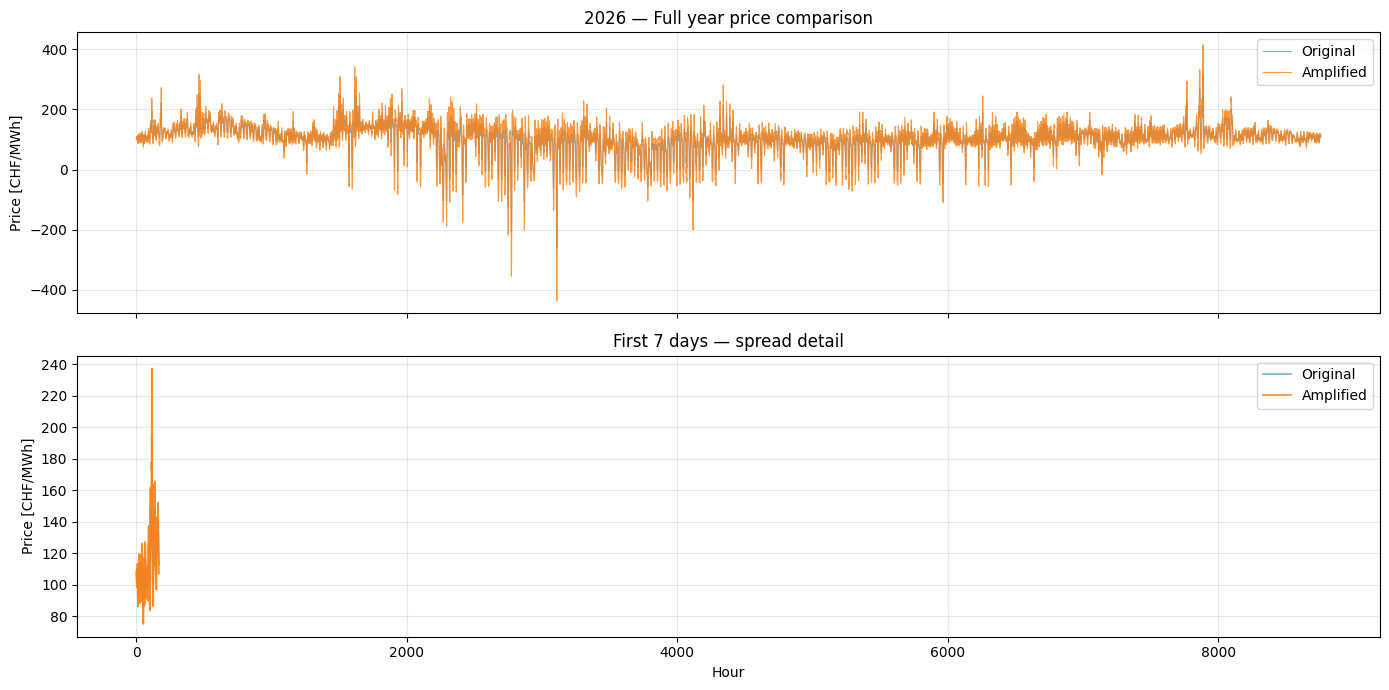

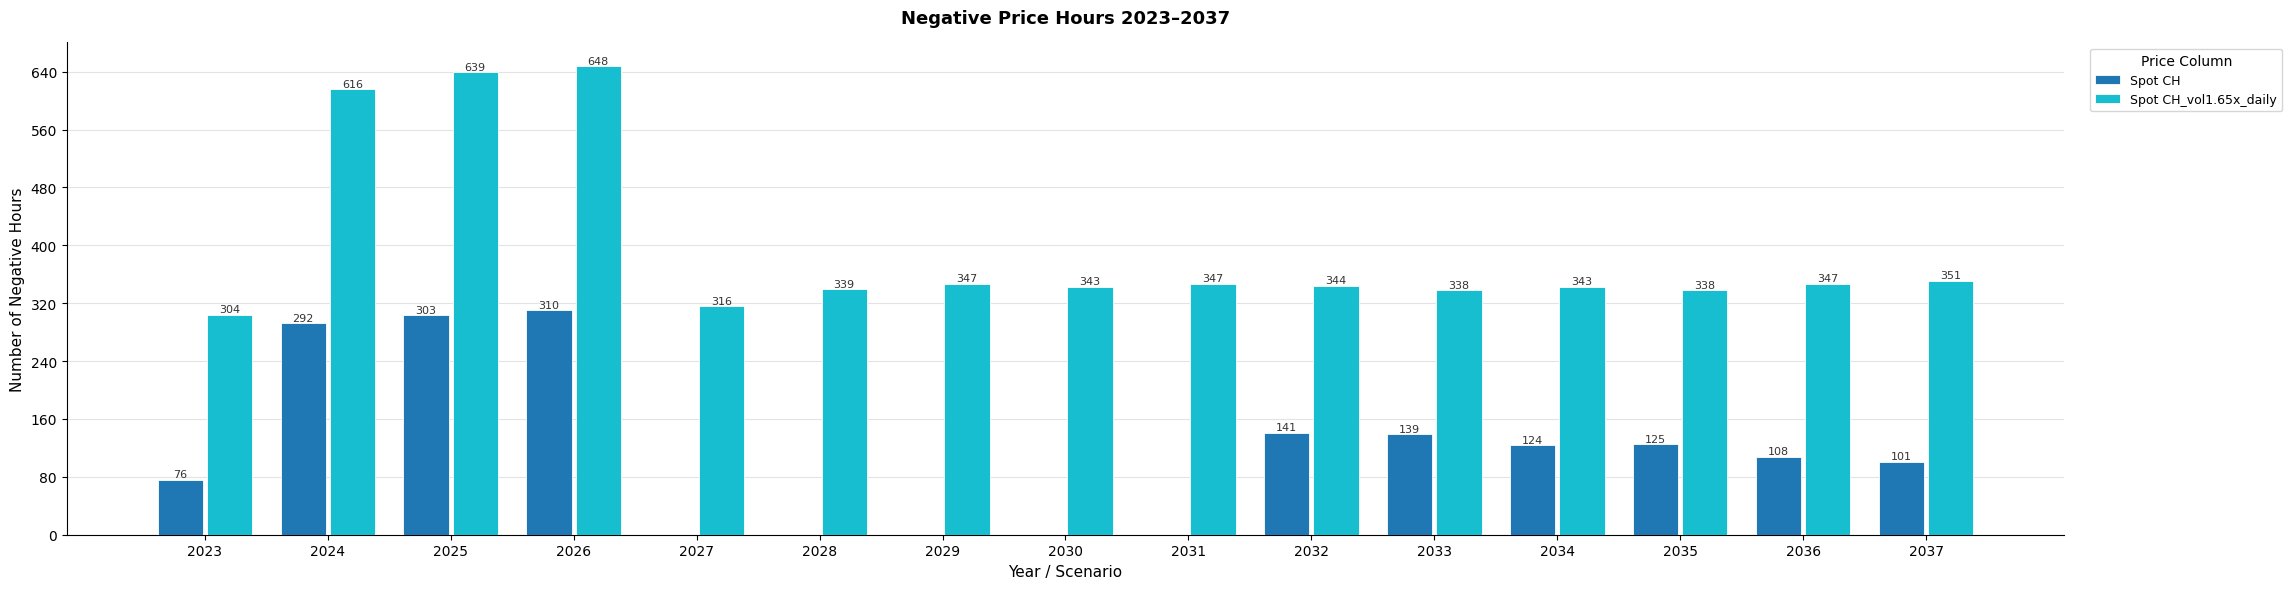

       Spot CH  Spot CH_vol1.65x_daily
Label                                 
2023        76                     304
2024       292                     616
2025       303                     639
2026       310                     648
2027         0                     316
2028         0                     339
2029         0                     347
2030         0                     343
2031         0                     347
2032       141                     344
2033       139                     338
2034       124                     343
2035       125                     338
2036       108                     347
2037       101                     351


In [7]:
# ── Apply to each yearly DataFrame ────────────────────────────────────────────
FACTOR  = 1.65          # wider spread
ANCHOR  = 'daily'      # preserve daily average prices
# FLOOR   = 0.0          # no negative prices

list_prices_amplified: list[pd.DataFrame] = [
    amplify_volatility(
        df,
        price_col='Spot CH',       # ← adjust to your actual column name
        date_col='Date',
        factor=FACTOR,
        anchor=ANCHOR,
        # floor=FLOOR
    )
    for df in list_prices
]


df_first_year   = list_prices_amplified[3]
year_first      = df_first_year['Date'].dt.year.iloc[0]
amplified_col   = f'Spot CH_vol{FACTOR}x_{ANCHOR}'   # matches generated column name

plot_volatility_comparison(df_first_year, 'Spot CH', amplified_col, year_first)

# One df — bars represent each price column
# summary = count_negative_hours(
#     data       = list_prices[0],
#     price_cols = ['Spot CH', 'Spot CH_vol1.5x_daily'],
# )

# Multiple dfs — groups represent years, bars within each group are columns
summary = count_negative_hours(
    data       = list_prices_amplified,                              # list of yearly dfs
    price_cols = ['Spot CH', f'Spot CH_vol{FACTOR}x_{ANCHOR}'],    # columns to compare
    title      = 'Negative Price Hours 2023–2037'
)
print(summary)


In [8]:
import logging
import pandas as pd
from pathlib import Path
from res_opt_core import Battery, Grid, EnergyModel, DayAhead

# ── Logger setup ───────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ── Output directory ───────────────────────────────────────────────────────────
output_spot_dir = Path(
    r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar'
    r'\Model_BESS\bess-optimierung-tool-py312\bess-behind-the-meter'
    r'\output\results\Spot-Analyse'
)
output_spot_dir.mkdir(parents=True, exist_ok=True)

# ── Control flags ─────────────────────────────────────────────────────────────
save_outputs: bool = True

# ── Lists built in Step 1 ────────────────────────────────────────────────────
list_of_yearly_prices = list_prices_amplified  # list[pd.DataFrame], one per year



# ✅ Use a plain list to collect rows — convert to DataFrame after the loop
objective_rows: list[dict] = []

# ── Arbitrage optimisation loop ───────────────────────────────────────────────
for df_prices in list_of_yearly_prices:

    year: int = df_prices['Date'].dt.year.iloc[0]
    start_optimization = pd.Timestamp(f'{year}-01-01')

    # ── Battery configuration ─────────────────────────────────────────────────────
    bess = Battery(
        name='bess',
        energy_capacity=2,
        power_nominal=1,
    )

    # Build the hourly DatetimeIndex for the full year
    idx = pd.date_range(start=start_optimization, freq='h', periods=len(df_prices))

    # Assign DatetimeIndex before passing into the optimizer
    df_prices = df_prices.copy()
    df_prices.index = idx

    logger.info("Running arbitrage optimisation for year %d ...", year)

    spot_market = DayAhead(
        name='spot_DA_CH',
        price_curve=df_prices[f'Spot CH_vol{FACTOR}x_{ANCHOR}'],
        market_time_unit='hour'
    )

    model = EnergyModel(
        name='spot_optimization',
        num_steps=len(df_prices.index),
        slot_length='hour',
        solver='scip'
    )

    grid = Grid(
        assets=[bess],
        markets=[spot_market]
    )

    model.add_component(spot_market)
    model.add_component(bess)
    model.add_component(grid)
    model.build_and_run(silent=False)

    df_results = model.results.timeseries_to_pandas()

    # ✅ Collect one dict per year — clean and safe
    objective_rows.append({
        'year': year,
        'objective_value': model.results.objective_value  # scalar float
    })

    if save_outputs:
        out_path = output_spot_dir / f"Arbitrage_{year}.csv"
        df_results.to_csv(out_path, index=True, encoding='utf-8-sig')
        logger.info("Battery arbitrage optimisation saved at %s", out_path)

# ✅ Build the summary DataFrame once, after the loop
objective_value = pd.DataFrame(objective_rows).set_index('year')
print(objective_value)

# ── Save summary ──────────────────────────────────────────────────────────────
objective_value.to_csv(output_spot_dir / 'return_per_year.csv', encoding='utf-8-sig')
logger.info("Objective values saved.")


SCIP version 10.0.2 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.2] [GitHash: b8eaf989f9]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 8.0.2         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: cfadddc4]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.2           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.88.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.7.1          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 4.0.4 